In [32]:
import gymnasium_env as drausp_env
import numpy as np
from pathlib import Path

from instance_reader import get_instance_data
import matplotlib.pyplot as plt

data_path = Path("../instances/lion18s/SA01.txt")

In [33]:
DRAUSP_data = get_instance_data(data_path)

K = DRAUSP_data.num_slots
T_d = DRAUSP_data.num_requests
C_k = DRAUSP_data.capacity_vector
instance = DRAUSP_data.instance
print(K)
print(T_d)
print(C_k)
print(instance)

4
50
[10, 10, 10, 10]
[[41, 1, 1, 0, 0], [39, 1, 1, 0, 0], [20, 1, 3, 0, 0], [61, 2, 1, 0, 0], [18, 2, 1, 0, 0], [23, 1, 4, 0, 0], [25, 1, 1, 0, 0], [13, 1, 1, 0, 0], [77, 1, 1, 0, 0], [8, 1, 2, 0, 0], [25, 1, 3, 0, 0], [74, 1, 1, 0, 0], [39, 1, 3, 0, 0], [54, 3, 2, 0, 0], [70, 1, 3, 0, 0], [71, 1, 1, 0, 0], [55, 1, 1, 0, 0], [9, 1, 1, 0, 0], [96, 1, 1, 0, 0], [63, 3, 2, 0, 0], [50, 3, 2, 0, 0], [20, 1, 1, 0, 0], [43, 1, 2, 0, 0], [74, 1, 2, 0, 0], [62, 1, 1, 0, 0], [60, 1, 1, 0, 0], [22, 1, 1, 0, 0], [81, 1, 2, 0, 0], [92, 1, 1, 0, 0], [80, 1, 1, 0, 0], [38, 2, 1, 0, 0], [84, 1, 1, 0, 0], [39, 1, 2, 0, 0], [88, 2, 1, 0, 0], [69, 1, 3, 0, 0], [21, 2, 1, 0, 0], [15, 1, 1, 0, 0], [47, 3, 1, 0, 0], [67, 1, 1, 0, 0], [18, 1, 1, 0, 0], [87, 1, 1, 0, 0], [58, 1, 2, 0, 0], [34, 2, 1, 0, 0], [8, 1, 1, 0, 0], [97, 1, 1, 0, 0], [73, 1, 1, 0, 0], [54, 1, 1, 0, 0], [69, 2, 1, 0, 0], [79, 1, 2, 0, 0], [9, 1, 2, 0, 0]]


In [34]:
env = drausp_env.DrauspEnv(K=K, T_d=T_d, C_k=C_k, instance=instance, render_mode="human", fixed_request_length=2)

In [35]:
from dqn_agent import DQNAgent
from lattice_dqn import LatticeDQNNetwork
agent = DQNAgent(env, QnetworkClass=LatticeDQNNetwork, monotonicity_penalty=False)

In [36]:
reward_history, monotonicity_violations = agent.train(num_episodes=1000)

KeyboardInterrupt: 

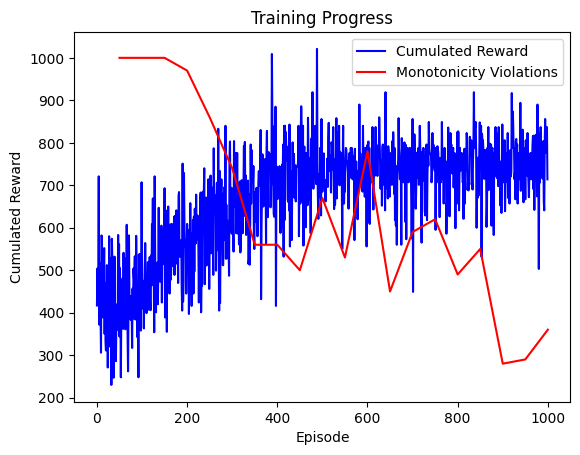

In [ ]:
plt.plot(reward_history, color = "blue", label="Cumulated Reward")
plt.plot([x[0] for x in monotonicity_violations], [x[1]*1000 for x in monotonicity_violations], color = "red", label="Monotonicity Violations")
plt.xlabel("Episode")
plt.ylabel("Cumulated Reward")
plt.title("Training Progress")
plt.legend()
plt.show()

In [ ]:
import torch

net = agent.policy_net
K = net.K

# Einen echten State holen
obs, _ = env.reset()
state_t = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)

with torch.no_grad():
    q_dqn   = net.dqn(state_t)
    q_total = net(state_t)
    bonus   = q_total - q_dqn

print(f"Q_dqn:   {q_dqn.numpy().flatten()}")
print(f"Bonus:   {bonus.numpy().flatten()[0]:.3f}")
print(f"Q_total: {q_total.numpy().flatten()}")

Q_dqn:   [264.57553 294.44    292.8773  291.76245]
Bonus:   4.512
Q_total: [269.0872  298.95166 297.38895 296.2741 ]


Teste ob der Bonus einen wirklichen Einfluss hat

In [ ]:
import torch

net = agent.policy_net
K = net.K

# Einen echten State holen
obs, _ = env.reset()
state_t = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)

with torch.no_grad():
    q_dqn   = net.dqn(state_t)
    q_total = net(state_t)
    bonus   = q_total - q_dqn

print(f"Q_dqn:   {q_dqn.numpy().flatten()}")
print(f"Bonus:   {bonus.numpy().flatten()[0]:.3f}")
print(f"Q_total: {q_total.numpy().flatten()}")

Q_dqn:   [264.57553 294.44    292.8773  291.76245]
Bonus:   4.512
Q_total: [269.0872  298.95166 297.38895 296.2741 ]


Bonus erfüllt die Monotonieeigenschaft

In [ ]:
for c_val in [0.0, 5.0, 10.0]:
    c_raw = torch.tensor([[c_val] * K], dtype=torch.float32)
    with torch.no_grad():
        c_cal = torch.cat(
            [cal(c_raw[:, k:k+1].double()).float()
             for k, cal in enumerate(net.c_calibrators)],
            dim=1,
        )
        bonus = net.c_lattice(c_cal.double()).float().item()
    print(f"C_k = {c_val:.0f}  →  Bonus = {bonus:.3f}")

C_k = 0  →  Bonus = 1.741
C_k = 5  →  Bonus = 4.416
C_k = 10  →  Bonus = 4.512
